<a href="https://colab.research.google.com/github/mishti127/Deep-learning/blob/main/Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import math
def alpha_beta(depth, node_index, is_max, values, alpha, beta, max_depth):
    if depth == max_depth:
        return values[node_index]
    if is_max:
        best = -math.inf
        for i in range(2):
            val = alpha_beta(depth + 1, node_index * 2 + i,
                             False, values, alpha, beta, max_depth)
            best = max(best, val)
            alpha = max(alpha, best)
            if beta <= alpha:
                break
        return best
    else:
        best = math.inf
        for i in range(2):
            val = alpha_beta(depth + 1, node_index * 2 + i,
                             True, values, alpha, beta, max_depth)
            best = min(best, val)
            beta = min(beta, best)
            if beta <= alpha:
                break
        return best
if __name__ == "__main__":
    values = [3, 5, 6, 9, 1, 2, 0, -1]
    max_depth = 3
    result = alpha_beta(0, 0, True, values, -math.inf, math.inf, max_depth)
    print("Optimal value:", result)

Optimal value: 5


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 51ms/step - loss: 0.2945 - val_loss: 0.1963
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 54ms/step - loss: 0.1828 - val_loss: 0.1727
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.1683 - val_loss: 0.1639
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - loss: 0.1623 - val_loss: 0.1590
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.1592 - val_loss: 0.1568
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - loss: 0.1573 - val_loss: 0.1551
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 50ms/step - loss: 0.1561 - val_loss: 0.1542
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - loss: 0.1552 - val_loss: 0.1537
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 20s 48ms/step - loss: 0.1546 - val_loss: 0.1528
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 0.1541 - val_loss: 0.1525
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 51ms/step - loss: 0.153

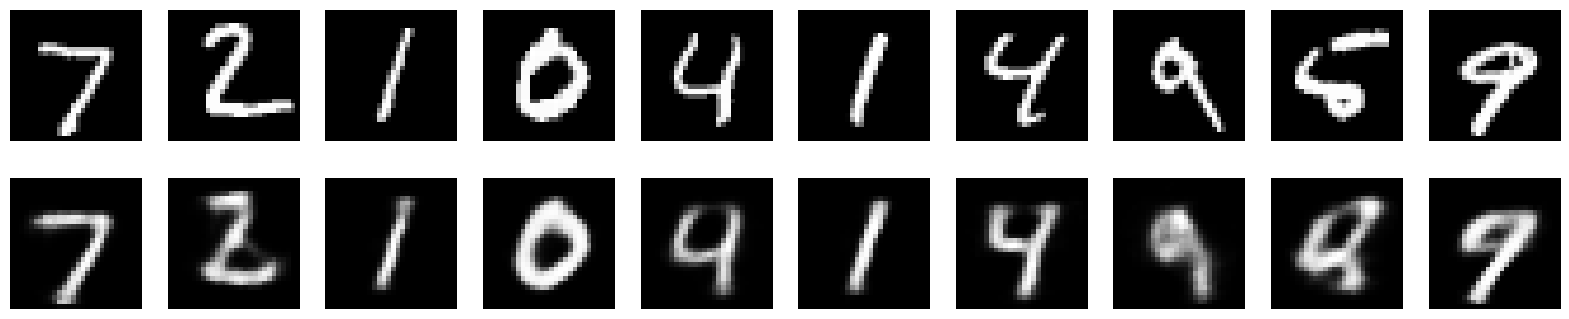

In [1]:
############
#
# Regularized Deep Autoencoder
# (with L2 weight decay)
#
############

### Import libraries
import tensorflow as tf
from tensorflow import keras
from keras import layers, regularizers
import matplotlib.pyplot as plt
import numpy as np

### Load MNIST dataset
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize pixel values to range 0–1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images from 28x28 → 784 pixels
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

### Hyperparameters
input_dim = 784          # 28x28 images
encoding_dim1 = 512       # first hidden layer
encoding_dim2 = 256       # second hidden layer (bottleneck)
encoding_dim3 = 128       # third hidden layer (optional smaller bottleneck)
reg_factor = 1e-4        # L2 regularization factor

### Encoder
input_img = keras.Input(shape=(input_dim,))

# First hidden layer with L2 regularization
encoded = layers.Dense(
    encoding_dim1,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(input_img)

# Second hidden layer
encoded = layers.Dense(
    encoding_dim2,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(encoded)

# Third hidden layer (bottleneck)
encoded = layers.Dense(
    encoding_dim3,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(encoded)

### Decoder
# Mirror the encoder architecture
decoded = layers.Dense(
    encoding_dim2,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(encoded)

decoded = layers.Dense(
    encoding_dim1,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(decoded)

# Output layer reconstructs original 784-pixel image
decoded = layers.Dense(
    input_dim,
    activation="sigmoid",
    kernel_regularizer=regularizers.l2(reg_factor)
)(decoded)

### Autoencoder model
autoencoder = keras.Model(inputs=input_img, outputs=decoded)

### Compile model
# optimizer=adam → standard choice for training deep networks
# loss=binary_crossentropy → works well for normalized pixel values
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

### Train model
history = autoencoder.fit(
    x_train, x_train,             # input = output for autoencoder
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

### Reconstruct test images
decoded_imgs = autoencoder.predict(x_test)

### Plot original vs reconstructed images
n = 10  # number of images to display
plt.figure(figsize=(20,4))
for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.axis("off")

    # Reconstructed image
    ax = plt.subplot(2, n, i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.show()

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 0.2531 - val_loss: 0.1734
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.1562 - val_loss: 0.1406
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1340 - val_loss: 0.1258
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - loss: 0.1233 - val_loss: 0.1180
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1167 - val_loss: 0.1130
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.1124 - val_loss: 0.1093
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 0.1094 - val_loss: 0.1067
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - loss: 0.1072 - val_loss: 0.1050
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 0.1053 - val_loss: 0.1035
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - loss: 0.1037 - val_loss: 0.1017
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


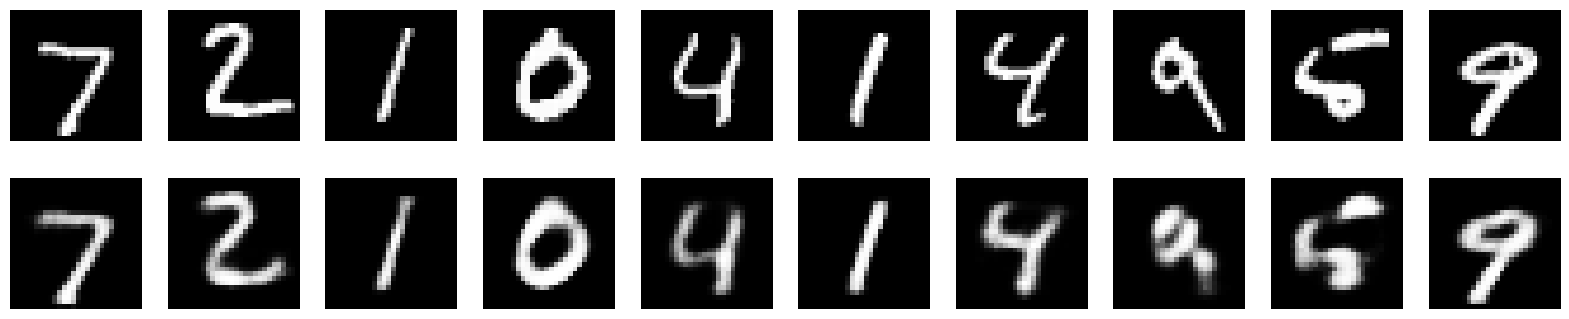

In [3]:
# Autoencoders
#
###########
### Import packages
import tensorflow as tf   	# build and train the neural network
from tensorflow.keras import layers  	# create neural network layers
from tensorflow.keras import models 	# define the complete model
import matplotlib.pyplot as plt 	# display images

### Load MNIST dataset
# Loads the MNIST dataset, which contains images of handwritten digits (0–9).
# x_train has training images.
# x_test has testing images.
# _ means we ignore the labels because autoencoders do not need them.

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

### Normalize pixel values
# Pixel values in images range from 0 to 255.
# Dividing by 255 converts them to 0–1 range.
# Helps the neural network learn better.

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

### Flatten images (28x28 → 784)
# Each image is 28 × 28 pixels.
# Neural networks often need 1D vectors, so convert:28 × 28 = 784 pixels
# Each image becomes a 784-length vector.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

### Encoder
# Input(shape=(784,)) - input layer for 784 pixel values.
# Dense layers gradually reduce the data size:
# 784 to 128
# 128 to 64
# 64 to 32
# The 32-unit layer is called the bottleneck layer, which stores the compressed representation of the image.

input_img = layers.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)  # bottleneck layer

### Decoder
# The decoder reconstructs the image by expanding the compressed data:
# 32 to 64
# 64 to 128
# 128 to 784
# The final layer outputs 784 values, which represent the reconstructed image pixels.
# sigmoid ensures output values stay between 0 and 1.

decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

### Autoencoder model
# connects the encoder and decoder into one complete model.
# Input → Encoder → Compressed Representation → Decoder → Reconstructed Image.

autoencoder = models.Model(input_img, decoded)

### Compile model
# optimizer = adam - adjusts weights to improve learning.
# loss = binary_crossentropy - measures how close reconstructed images are to original images.

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

### Train model

# The model learns by comparing input images with their own outputs.
# epochs=10 - training repeats 10 times.
# batch_size=256 - processes 256 images at a time.
# shuffle=True - randomizes training data.
# Validation checks performance using test data.


history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

### Reconstruct images
# The trained model tries to recreate the test images.

decoded_imgs = autoencoder.predict(x_test)

### Plot original vs reconstructed images
# Original Images
# Reconstructed Images (from compressed data)
# If the model trained well, the reconstructed images will look very similar to the originals.

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    plt.axis("off")

plt.show()

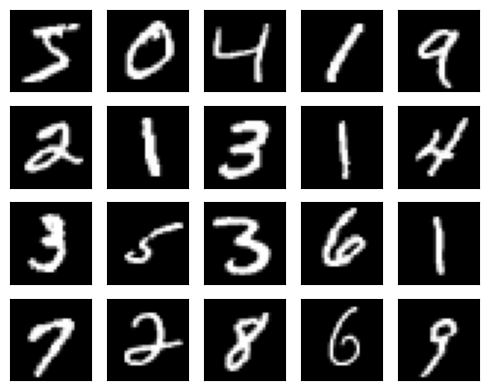

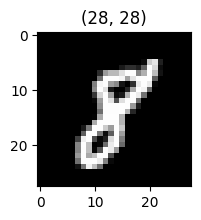

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/activations/leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Epoch:   1/100 | D Loss: 0.3903 | G Loss: 4.0625
Epoch:   2/100 | D Loss: 0.4035 | G Loss: 3.9524
Epoch:   3/100 | D Loss: 0.4088 | G Loss: 3.9844
Epoch:   4/100 | D Loss: 0.4192 | G Loss: 3.9659
Epoch:   5/100 | D Loss: 0.4356 | G Loss: 3.8964
Epoch:   6/100 | D Loss: 0.4513 | G Loss: 3.8398
Epoch:   7/100 | D Loss: 0.4637 | G Loss: 3.8100
Epoch:   8/100 | D Loss: 0.4747 | G Loss: 3.7661
Epoch:   9/100 | D Loss: 0.4859 | G Loss: 3.7311
Epoch:  10/100 | D Loss: 0.4972 | G Loss: 3.6857
Epoch:  11/100 | D Loss: 0.5059 | G Loss: 3.6575
Epoch:  12/100 | D Loss: 0.5094 | G Loss: 3.6619
Epoch:  13/100 | D Loss: 0.5156 | G Loss: 3.6434
Epoch:  14/100 | D Loss: 0.5231 | G Loss: 3.6188
Epoch:  15/100 | D Loss: 0.5294 | G Loss: 3.6056
Epoch:  16/100 | D Loss: 0.5344 | G Loss: 3.5941
Epoch:  17/100 | D Loss: 0.5386 | G Loss: 3.5876
Epoch:  18/100 | D Loss: 0.5435 | G Loss: 3.5725
Epoch:  19/100 | D Loss: 0.5494 | G Loss: 3.5470
Epoch:  20/100 | D Loss: 0.5549 | G Loss: 3.5214
Epoch:  21/100 | D L

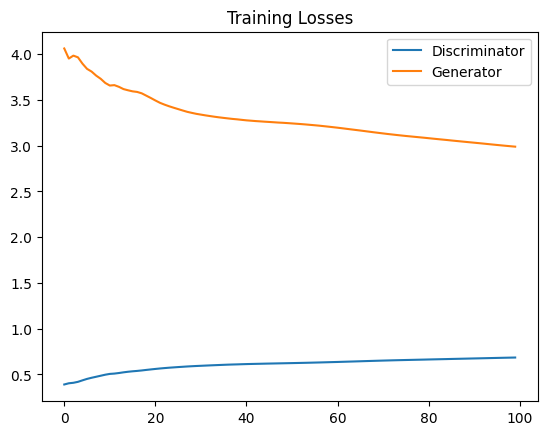

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step


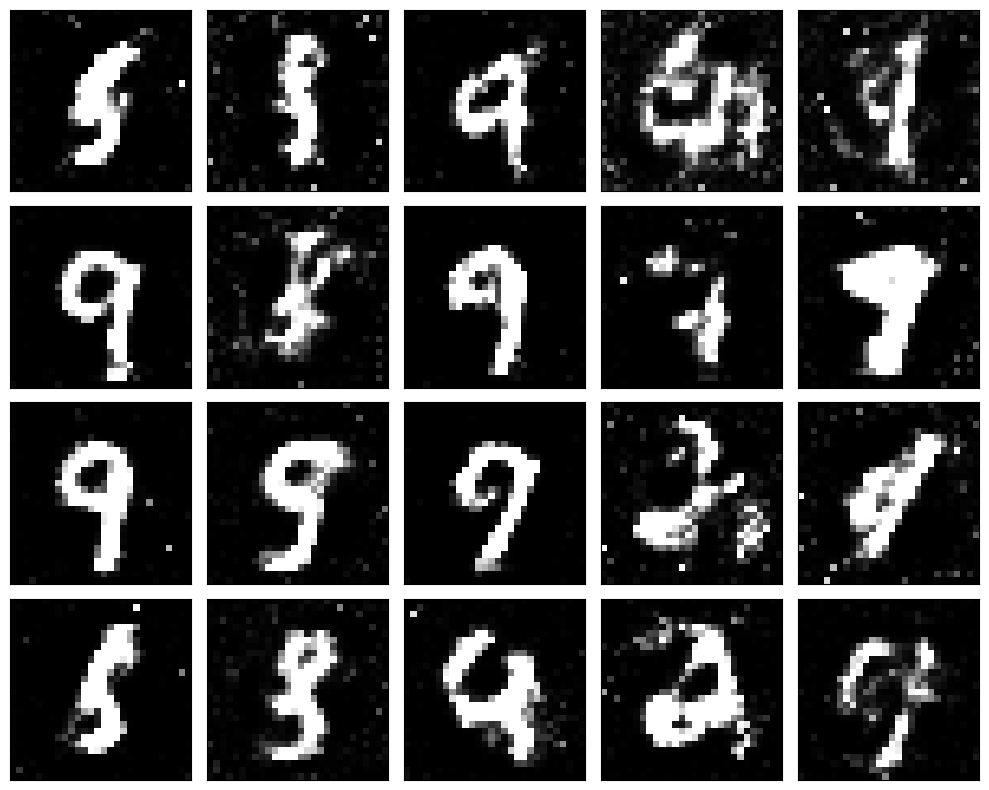

In [4]:
# Import required libraries
import numpy as np
import keras
import keras.backend as K
from keras.layers import Dense, Activation, LeakyReLU
from keras.models import Sequential
from keras.optimizers import Adam
import matplotlib.pyplot as plt

# Load MNIST dataset (handwritten digits)
(X_train, y_train), (X_test, y_test) = keras.datasets.mnist.load_data()

# -----------------------------------------------------------
# Visualization of sample training images
# -----------------------------------------------------------
plt.figure(figsize=(5, 4))
for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train[i], cmap='gray')   # display grayscale image
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()

# Display shape of a single sample image
sample = X_train[17]
plt.figure(figsize=(3, 2))
plt.title(sample.shape)   # expected shape: (28, 28)
plt.imshow(sample, cmap='gray')
plt.show()

# -----------------------------------------------------------
# Function to generate latent space samples
# -----------------------------------------------------------
def make_latent_samples(n_samples, sample_size):
    """
    Generates random samples from a normal distribution.

    Parameters:
        n_samples (int): Number of samples
        sample_size (int): Dimension of latent vector

    Returns:
        numpy.ndarray: Random latent vectors
    """
    return np.random.normal(loc=0, scale=1, size=(n_samples, sample_size))

# -----------------------------------------------------------
# Function to control trainability of model layers
# -----------------------------------------------------------
def make_trainable(model, trainable):
    """
    Sets the trainable property for all layers in a model.

    Parameters:
        model: Keras model
        trainable (bool): Trainable flag
    """
    for layer in model.layers:
        layer.trainable = trainable

# -----------------------------------------------------------
# GAN model creation function
# -----------------------------------------------------------
def make_simple_GAN(sample_size,
                    g_hidden_size,
                    d_hidden_size,
                    leaky_alpha,
                    g_learning_rate,
                    d_learning_rate):
    """
    Constructs Generator, Discriminator, and GAN models.
    """
    K.clear_session()

    # Generator model
    generator = Sequential([
        Dense(g_hidden_size, input_shape=(sample_size,)),
        LeakyReLU(alpha=leaky_alpha),
        Dense(784),
        Activation('tanh')  # output scaled between [-1, 1]
    ], name='generator')

    # Discriminator model
    discriminator = Sequential([
        Dense(d_hidden_size, input_shape=(784,)),
        LeakyReLU(alpha=leaky_alpha),
        Dense(1),
        Activation('sigmoid')  # binary classification
    ], name='discriminator')

    # Combined GAN model
    gan = Sequential([
        generator,
        discriminator
    ])

    # Compile discriminator
    discriminator.compile(
        optimizer=Adam(learning_rate=d_learning_rate),
        loss='binary_crossentropy'
    )

    # Freeze discriminator while training GAN
    make_trainable(discriminator, False)

    # Compile GAN
    gan.compile(
        optimizer=Adam(learning_rate=g_learning_rate),
        loss='binary_crossentropy'
    )

    return gan, generator, discriminator

# -----------------------------------------------------------
# Data preprocessing
# -----------------------------------------------------------
def preprocess(x):
    """
    Reshapes and normalizes image data to range [-1, 1].
    """
    x = x.reshape(-1, 784)     # flatten 28x28 images
    x = np.float32(x)
    x = (x / 255.0 - 0.5) * 2  # normalization
    return np.clip(x, -1, 1)

# Convert training and test data
X_train_real = preprocess(X_train)
X_test_real  = preprocess(X_test)

# -----------------------------------------------------------
# Reverse preprocessing for visualization
# -----------------------------------------------------------
def deprocess(x):
    """
    Converts normalized data back to image format.
    """
    x = (x / 2 + 1) * 255
    x = np.clip(x, 0, 255)
    x = np.uint8(x)
    return x.reshape(28, 28)

# -----------------------------------------------------------
# Label generation for GAN training
# -----------------------------------------------------------
def make_labels(size):
    """
    Creates labels for real and fake samples.
    """
    return np.ones((size, 1)), np.zeros((size, 1))

# -----------------------------------------------------------
# Hyperparameters
# -----------------------------------------------------------
sample_size     = 100
g_hidden_size   = 128
d_hidden_size   = 128
leaky_alpha     = 0.01
g_learning_rate = 0.0001
d_learning_rate = 0.001
epochs          = 100
batch_size      = 64
eval_size       = 16
smooth          = 0.1  # label smoothing

# Training labels
y_train_real, y_train_fake = make_labels(batch_size)
y_eval_real,  y_eval_fake  = make_labels(eval_size)

# Create models
gan, generator, discriminator = make_simple_GAN(
    sample_size,
    g_hidden_size,
    d_hidden_size,
    leaky_alpha,
    g_learning_rate,
    d_learning_rate
)

# -----------------------------------------------------------
# GAN Training Loop
# -----------------------------------------------------------
losses = []

for e in range(epochs):
    for i in range(len(X_train_real) // batch_size):

        # Select real images
        X_batch_real = X_train_real[i * batch_size:(i + 1) * batch_size]

        # Generate fake images
        latent_samples = make_latent_samples(batch_size, sample_size)
        X_batch_fake = generator.predict_on_batch(latent_samples)

        # Train discriminator
        make_trainable(discriminator, True)
        discriminator.train_on_batch(X_batch_real, y_train_real * (1 - smooth))
        discriminator.train_on_batch(X_batch_fake, y_train_fake)

        # Train generator via GAN (discriminator frozen)
        make_trainable(discriminator, False)
        gan.train_on_batch(latent_samples, y_train_real)

    # -------------------------------------------------------
    # Evaluation after each epoch
    # -------------------------------------------------------
    X_eval_real = X_test_real[np.random.choice(len(X_test_real), eval_size, replace=False)]

    latent_samples = make_latent_samples(eval_size, sample_size)
    X_eval_fake = generator.predict_on_batch(latent_samples)

    d_loss  = discriminator.test_on_batch(X_eval_real, y_eval_real)
    d_loss += discriminator.test_on_batch(X_eval_fake, y_eval_fake)
    g_loss  = gan.test_on_batch(latent_samples, y_eval_real)

    losses.append((d_loss, g_loss))

    print("Epoch: {:>3}/{} | D Loss: {:>6.4f} | G Loss: {:>6.4f}".format(
        e + 1, epochs, d_loss, g_loss))

# -----------------------------------------------------------
# Plot training losses
# -----------------------------------------------------------
losses = np.array(losses)

plt.figure()
plt.plot(losses.T[0], label='Discriminator')
plt.plot(losses.T[1], label='Generator')
plt.title("Training Losses")
plt.legend()
plt.show()

# -----------------------------------------------------------
# Generate new digit samples
# -----------------------------------------------------------
latent_samples = make_latent_samples(20, sample_size)
generated_digits = generator.predict(latent_samples)

plt.figure(figsize=(10, 8))
for i in range(20):
    img = deprocess(generated_digits[i])
    plt.subplot(4, 5, i + 1)
    plt.imshow(img, cmap='gray')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()